In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.5 MB/s eta 0:00:00


## 1. Problem Context

We study a dynamic industrial process where the objective is to predict the output variable **CO₂ concentration** based on:
- Its own past values (process inertia)
- A manipulated input variable (**Gas Input Rate**)

This is a typical **process modeling / soft sensor** problem, where understanding the temporal relationship between inputs and outputs is critical before selecting a model.


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("yazanalshuaibi/gas-furnace")

print("Path to dataset files:", path)

100%|██████████| 1.43k/1.43k [00:00<00:00, 2.47MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/yazanalshuaibi/gas-furnace/versions/1


In [ ]:
import pandas as pd
import os
df = pd.read_csv(os.path.join(path,"gas-furnace.csv"))

### Load and Inspect the Data

Before any modeling:

We verify data integrity

Identify missing values

Understand scale and units

In [ ]:
df.head()


,InputGasRate,CO2
0,-0.109,53.8
1,0.000,53.6
2,0.178,53.5
3,0.339,53.5
4,0.373,53.4


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 296 entries, 0 to 295
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   InputGasRate  296 non-null    float64
 1   CO2           296 non-null    float64
dtypes: float64(2)
memory usage: 4.8 KB


**Why:**  
We need to confirm that:
- Data is numeric
- Time ordering is preserved
- No unexpected missing or corrupted values exist


---



### Basic Statistics of Input and Output


*  Reveals scale mismatch
*  Indicates variability
*  Helps detect constant or unstable signals






In [ ]:
df.describe()


,InputGasRate,CO2
count,296.000000,296.000000
mean,-0.056834,53.509122
std,1.072766,3.202121
min,-2.716000,45.600000
25%,-0.830000,51.200000
50%,0.000000,53.500000
75%,0.680500,56.000000
max,2.834000,60.500000


**Why:**  
Statistical summaries help us understand:
- Whether the output is stable or highly volatile
- Whether the input has enough variation to influence the output

In [ ]:
df.reset_index(drop=True, inplace=True)
df.head()


,InputGasRate,CO2
0,-0.109,53.8
1,0.000,53.6
2,0.178,53.5
3,0.339,53.5
4,0.373,53.4


### Time-Series Visualization


Time-series data must be visually inspected before modeling.

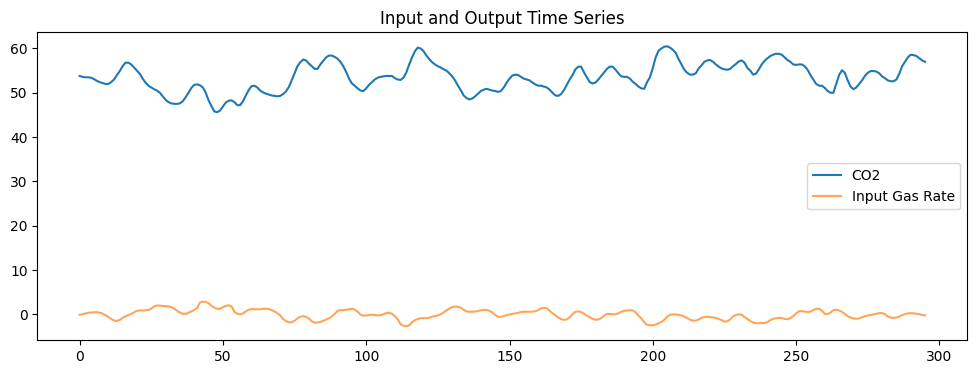

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot(df["CO2"], label="CO2")
plt.plot(df["InputGasRate"], label="Input Gas Rate", alpha=0.7)
plt.legend()
plt.title("Input and Output Time Series")
plt.show()


### Time-Series Interpretation (CO₂ & Gas Input)

- **CO₂ signal:** Varies smoothly with no sudden jumps, indicating a stable process with strong temporal dependence. Past CO₂ values are highly informative for forecasting future behavior.

- **Gas input rate:** Fluctuates around zero with higher-frequency, lower-magnitude variations. The weak immediate alignment with CO₂ suggests a delayed and filtered input–output relationship.

- **Overall system:** Exhibits inertia and time-delayed dynamics, motivating the use of autoregressive terms and lagged input features in modeling.


## 📊 Rolling Statistics

In the code below, we calculate the rolling mean and standard deviation for the strictly previous 20 days.

Notice the addition of .shift(1). This shifts the timeline down by one row before applying the 20-day window, deliberately excluding the current day's CO2 value. This ensures we only use historical data, preventing data leakage.

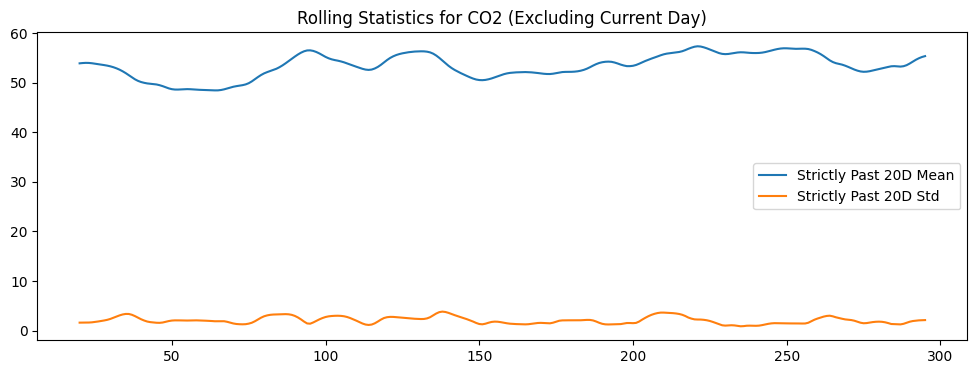

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

# Added .shift(1) to exclude the current row
plt.plot(df["CO2"].shift(1).rolling(20).mean(), label="Strictly Past 20D Mean")
plt.plot(df["CO2"].shift(1).rolling(20).std(), label="Strictly Past 20D Std")

plt.legend()
plt.title("Rolling Statistics for CO2 (Excluding Current Day)")
plt.show()

### Rolling Statistics Analysis (CO₂)

- **Rolling mean:** The average CO₂ value computed over a moving time window changes slowly and stays within a narrow range. This indicates that the typical CO₂ level does not drift significantly over time.

- **Rolling standard deviation:** The spread of CO₂ values within a moving window remains fairly constant, showing that the variability of the signal does not increase or decrease over time.

- **Overall behavior:** Both the average level and the variability of the CO₂ signal remain stable throughout the dataset.

- **Modeling relevance:** Because the CO₂ signal maintains a consistent level and variability, it can be modeled directly using past CO₂ values without applying additional transformations such as differencing.


### Important concept introduced here is Memory

**Why:**  
Autocorrelation answers:
- Does the past output influence the present?
- How many previous steps matter?

Strong autocorrelation indicates the need for autoregressive terms.


<Figure size 640x480 with 0 Axes>

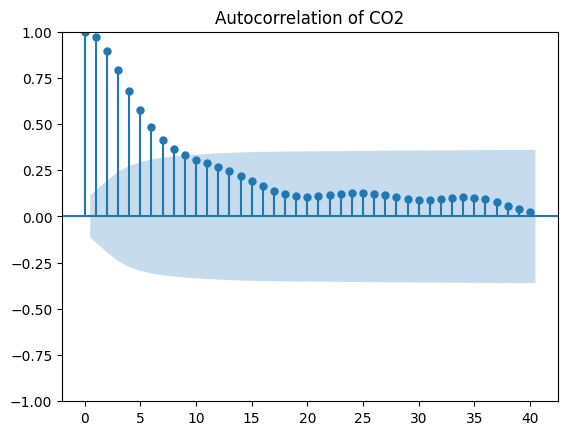

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf

plt.figure()
plot_acf(df["CO2"], lags=40)  # set lags to whatever range you want, e.g. 1–40
plt.title("Autocorrelation of CO2")
plt.show()

### Autocorrelation Analysis (CO₂)

- **What this plot shows:**  
  Each point measures how strongly the CO₂ value at one time step is related to its value several time steps earlier (called a *lag*).

- **Strong correlation at small lags:**  
  The autocorrelation is very high at lag 1 and decreases gradually as the lag increases. This means the current CO₂ value is strongly influenced by recent past values.

- **Slow decay of correlation:**  
  The correlation does not drop to zero immediately, indicating that the effect of past CO₂ values persists over multiple time steps rather than disappearing quickly.

- **Oscillating pattern:**  
  The alternating positive and negative correlations at larger lags suggest a repeating rise-and-fall behavior in the CO₂ signal rather than random noise.

- **Modeling relevance:**  
  The strong correlation at small lags confirms that past CO₂ values should be included as input features, and that using at least one previous CO₂ value is essential for accurate prediction.


###Partial Autocorrelation (Lag Importance)
**Why:**  
PACF helps decide:
- How many output lags should be included
- Whether AR(1) is sufficient

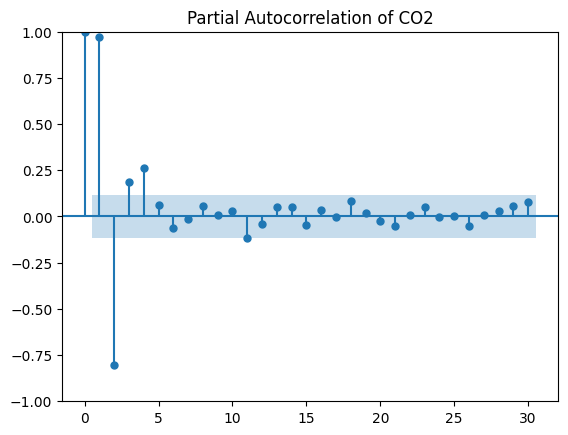

In [ ]:
from statsmodels.graphics.tsaplots import plot_pacf

plot_pacf(df["CO2"], lags=30)
plt.title("Partial Autocorrelation of CO2")
plt.show()


### Partial Autocorrelation Analysis (CO₂)

- **What this plot shows:**  
  Partial autocorrelation measures the **direct influence** of past CO₂ values on the current value, after removing the effects of all shorter lags.

- **Lag 1 (very strong positive):**  
  Indicates strong inertia and persistence; CO₂(t−1) is the dominant direct driver of CO₂(t).

- **Lag 2 (strong negative):**  
  Reveals a delayed **corrective or damping effect**, typical of feedback-controlled processes where earlier states trigger adjustment.

- **Lags 3–5 (moderate positive):**  
  Suggest additional short-term memory, meaning the system response spans multiple time steps.

- **Higher lags (>5):**  
  Fall within the confidence bounds, indicating no meaningful direct influence.

- **Overall interpretation:**  
  The process exhibits strong inertia with delayed corrective feedback, consistent with a damped dynamic system.

- **Modeling takeaway:**  
  A low-order autoregressive model, such as **AR(2) or AR(3)**, is appropriate; higher-order lags are unlikely to add value.

Note: Lag 0 is trivial self-correlation and is never used for interpretation or modeling.


---




## CrossCorrelation
**Why:**  
Cross-correlation tells us:
- Whether the input affects the output
- After how many time steps the effect appears

A peak at lag > 0 indicates delayed influence.


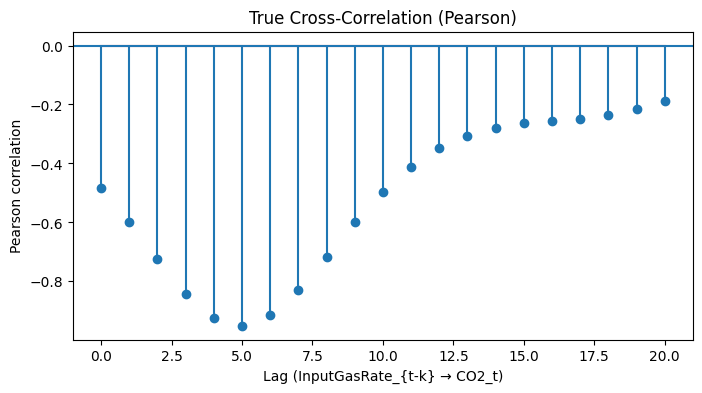

In [ ]:
import numpy as np
max_lag = 20
corrs = []

for k in range(max_lag + 1):
    corrs.append(
        np.corrcoef(
            df["InputGasRate"].shift(k).dropna(),
            df["CO2"].iloc[k:]
        )[0,1]
    )

plt.figure(figsize=(8,4))
plt.stem(range(max_lag + 1), corrs)
plt.axhline(0)
plt.xlabel("Lag (InputGasRate_{t-k} → CO2_t)")
plt.ylabel("Pearson correlation")
plt.title("True Cross-Correlation (Pearson)")
plt.show()


### But can we trust it? look up prewhitend Cross correlation for more advance way to pick

- we will pick the most 3 correlated features
- another way to do it is to use a model with feature importance
- lags are one of the most important things in time-series problem, one extra or less lag could significantly destory the model

In [ ]:

df["GasRate_lag4"] = df["InputGasRate"].shift(4)
df["GasRate_lag5"] = df["InputGasRate"].shift(5)
df["GasRate_lag6"] = df["InputGasRate"].shift(6)

df["CO2_lag1"] = df["CO2"].shift(1)
df["CO2_lag2"] = df["CO2"].shift(2)
df["CO2_lag3"] = df["CO2"].shift(3)
df.head()


,InputGasRate,CO2,GasRate_lag4,GasRate_lag5,GasRate_lag6,CO2_lag1,CO2_lag2,CO2_lag3
0,-0.109,53.8,NaN,NaN,NaN,NaN,NaN,NaN
1,0.000,53.6,NaN,NaN,NaN,53.8,NaN,NaN
2,0.178,53.5,NaN,NaN,NaN,53.6,53.8,NaN
3,0.339,53.5,NaN,NaN,NaN,53.5,53.6,53.8
4,0.373,53.4,-0.109,NaN,NaN,53.5,53.5,53.6


In [ ]:
lag_df = df.dropna()

print("Correlation between features: ")
lag_df[[
    "InputGasRate",

    "GasRate_lag4",
    "GasRate_lag5",
    "GasRate_lag6",
    "CO2_lag1",
    "CO2_lag2",
    "CO2_lag3",
    "CO2"
]].corr()


Correlation between features: 


,InputGasRate,GasRate_lag4,GasRate_lag5,GasRate_lag6,CO2_lag1,CO2_lag2,CO2_lag3,CO2
InputGasRate,1.000000,0.531814,0.408072,0.318624,-0.394652,-0.330467,-0.289107,-0.484679
GasRate_lag4,0.531814,1.000000,0.952633,0.834427,-0.845316,-0.729345,-0.603693,-0.924759
GasRate_lag5,0.408072,0.952633,1.000000,0.952610,-0.927586,-0.848392,-0.732778,-0.950614
GasRate_lag6,0.318624,0.834427,0.952610,1.000000,-0.953703,-0.931127,-0.852507,-0.914983
CO2_lag1,-0.394652,-0.845316,-0.927586,-0.953703,1.000000,0.972644,0.899661,0.972764
CO2_lag2,-0.330467,-0.729345,-0.848392,-0.931127,0.972644,1.000000,0.972536,0.900085
CO2_lag3,-0.289107,-0.603693,-0.732778,-0.852507,0.899661,0.972536,1.000000,0.798626
CO2,-0.484679,-0.924759,-0.950614,-0.914983,0.972764,0.900085,0.798626,1.000000


### This is how the data looks like now


In [ ]:
lag_df

,InputGasRate,CO2,GasRate_lag4,GasRate_lag5,GasRate_lag6,CO2_lag1,CO2_lag2,CO2_lag3
6,0.461,52.7,0.178,0.000,-0.109,53.1,53.4,53.5
7,0.348,52.4,0.339,0.178,0.000,52.7,53.1,53.4
8,0.127,52.2,0.373,0.339,0.178,52.4,52.7,53.1
9,-0.180,52.0,0.441,0.373,0.339,52.2,52.4,52.7
10,-0.588,52.0,0.461,0.441,0.373,52.0,52.2,52.4
...,...,...,...,...,...,...,...,...
291,0.195,58.5,-0.204,-0.528,-0.740,58.6,58.0,57.0
292,0.131,58.3,0.034,-0.204,-0.528,58.5,58.6,58.0
293,0.017,57.8,0.204,0.034,-0.204,58.3,58.5,58.6
294,-0.182,57.3,0.253,0.204,0.034,57.8,58.3,58.5


###⏱️ Time-Based Train/Test Split
- Time-based splitting is sequential, preserves causality, and reflects real forecasting behavior.

- Random splitting mixes past and future → data leakage.

- Models must be trained on past data and tested on future data.

- This mimic how we really use the model in inference (train in past data to predict future).


In [ ]:
def time_split(df, test_size=0.2):
    # Fake date but same sampling rate
    df.index = pd.date_range("2026-01-01", periods=len(df), freq="1s")
    n = len(df)
    split = int((1 - test_size) * n)
    return df.iloc[:split], df.iloc[split:]

### Prepare the Dataset

In [ ]:
train, test = time_split(lag_df)

# Array to save all results
results = []

X_cols = [
    "InputGasRate",
    "GasRate_lag4",
    "GasRate_lag5",
    "GasRate_lag6",
    "CO2_lag1",
    "CO2_lag2",
    "CO2_lag3",
]

X_train = train[X_cols]
y_train = train["CO2"].values
X_test  = test[X_cols]
y_test = test["CO2"].values

### Error Metrics

- MAE shows average error in real units and is the best default metric.

- MSE strongly penalizes large errors but is hard to interpret.

- RMSE highlights spikes and instability in real units.

- MAPE measures relative error but fails when values are near zero.

- SMAPE stabilizes percentage error but can hide large absolute mistakes.


You can read more about it [HERE](https://sulfuric-staircase-510.notion.site/Time-Series-Metrics-2fe92785b691809e9166f4c9d29d7e17)


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import numpy as np

def evaluate(y_true, y_pred, name):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # SMAPE needs custom implementation
    smape = np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred))) * 100

    return {
        "model": name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAPE": mean_absolute_percentage_error(y_true, y_pred) * 100,  # sklearn returns decimal, multiply by 100 for percentage
        "SMAPE": smape
    }

###Baselines in Time-Series Models

- A baseline is a simple reference used to judge model usefulness.
- It represents the minimum acceptable performance.
- If a model cannot beat the baseline, it adds no value.




> Assumes:
```
y(t) = y(t-1)
```



- Note: beating the Baseline in time-series problems sometimes is hard :)

In [ ]:
# Baseline is the t-1 value, which is hard to beat!
yhat_naive = test["CO2_lag1"].values

results.append(evaluate(y_test, yhat_naive, "Baseline: CO2(t-1)"))

###Linear Regression

In [ ]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

yhat_lr = lr.predict(X_test)
results.append(evaluate(y_test, yhat_lr, "Linear Regression"))

###Linear Regression with - Ridge regularization (L2)

In [ ]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

yhat_ridge = ridge.predict(X_test)
results.append(evaluate(y_test, yhat_ridge, "Linear Regression - Ridge regularization (L2)"))


### let's plot the predectioin of the models against baseline and the actual values

In [ ]:
def plot_predictions(y_true, preds, labels):
    plt.figure(figsize=(12,4))
    plt.plot(y_true, label="True", linewidth=2)
    for yhat, lab in zip(preds, labels):
        plt.plot(yhat, label=lab)
    plt.legend()
    plt.title("Predictions comparison")
    plt.show()


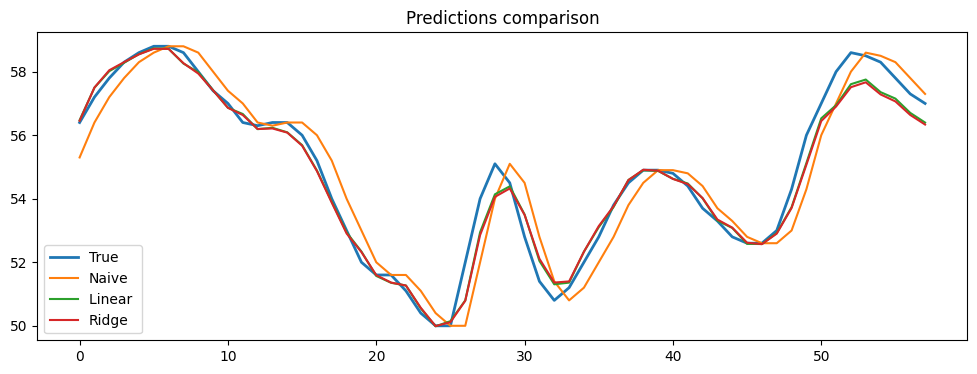

In [ ]:
plot_predictions(
    y_test,
    [yhat_naive, yhat_lr, yhat_ridge],
    ["Naive", "Linear ", "Ridge"]
)


In [ ]:
results_df = pd.DataFrame(results).sort_values("MAE")
results_df


,model,MAE,RMSE,MAPE,SMAPE
1,Linear Regression,0.321831,0.455883,0.583689,0.585871
2,Linear Regression - Ridge regularization (L2),0.342477,0.486359,0.620633,0.623171
0,Baseline: CO2(t-1),0.618966,0.786853,1.138253,1.140531


### Boosting Models (Random Forrest, XGboost, Catboost)

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=None,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

yhat_rf = rf.predict(X_test)
results.append(evaluate(y_test, yhat_rf, "Random Forest"))

In [ ]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=800,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    random_state=42,
    objective="reg:squarederror",
    n_jobs=-1
)
xgb.fit(X_train, y_train)

yhat_xgb = xgb.predict(X_test)
results.append(evaluate(y_test, yhat_xgb, "XGBoost"))

In [ ]:
from catboost import CatBoostRegressor

cb = CatBoostRegressor(
    iterations=2000,
    learning_rate=0.03,
    depth=6,
    l2_leaf_reg=3.0,
    loss_function="MAE",
    random_seed=42,
    verbose=False
)
cb.fit(X_train, train["CO2"])

yhat_cb = cb.predict(X_test)
results.append(evaluate(y_test, yhat_cb, "CatBoost"))

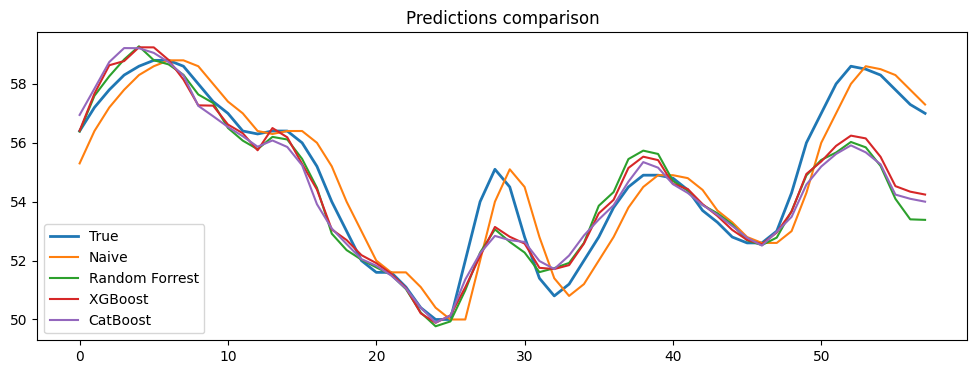

In [ ]:
plot_predictions(
    y_test,
    [yhat_naive,yhat_rf, yhat_xgb, yhat_cb ],
    ["Naive","Random Forrest", "XGBoost ", "CatBoost"]
)


In [ ]:
results_df = pd.DataFrame(results).sort_values("MAE")
results_df


,model,MAE,RMSE,MAPE,SMAPE
1,Linear Regression,0.321831,0.455883,0.583689,0.585871
2,Linear Regression - Ridge regularization (L2),0.342477,0.486359,0.620633,0.623171
0,Baseline: CO2(t-1),0.618966,0.786853,1.138253,1.140531
4,XGBoost,0.763145,1.133473,1.362618,1.379646
3,Random Forest,0.842918,1.293244,1.506659,1.529137
5,CatBoost,0.847767,1.256612,1.510970,1.531957


##Time Series models


## ARIMA(2,0,1) — One-Step Prediction

- **Model (2,0,1):**  
  Uses two past values (**AR(2)**) and the previous prediction error (**MA(1)**); no differencing.

- **Training:**  
  Fitted only on the first 80% of the data (`y_train`) to avoid leakage.

- **Constant term:**  
  `trend="c"` allows a non-zero mean level.

- **Constraints:**  
  Stationarity and invertibility are relaxed to improve convergence on real data.

- **Apply:**  
  `apply()` reuses learned parameters on the full series without refitting.

- **Prediction:**  
  `dynamic=False` performs one-step-ahead prediction using true past observations.

- **Evaluation:**  
  Test-window predictions are evaluated with MAE, RMSE, MAPE, and SMAPE.


In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

arima = SARIMAX(
    y_train,
    order=(2, 0, 1),
    seasonal_order=(0, 0, 0, 0),
    trend="c",
    enforce_stationarity=False,
    enforce_invertibility=False
)
arima_fit = arima.fit(disp=False)

# 2) Extend the fitted model with the FULL series (so it can see true past y's in test)
#    This does NOT refit parameters; it just runs the filter with fixed params.
fit_ext = arima_fit.apply(lag_df["CO2"])

# 3) One-step-ahead predictions on the test window (uses true past observations)
pred = fit_ext.get_prediction(start=int(0.8 * len(lag_df)), end=len(lag_df["CO2"])-1, dynamic=False)

yhat_arima = pred.predicted_mean.to_numpy()

# 4) Evaluate
results.append(evaluate(y_test, yhat_arima, "ARIMA(2,0,1) - 1step"))


## SARIMA(2,0,1)×(1,0,1,5) — One-Step Prediction

- **Model (2,0,1)×(1,0,1,5):**  
  Uses two past values (**AR(2)**), one past error (**MA(1)**), and a seasonal ARMA structure with period **5**.

- **Training:**  
  Fitted only on the first 80% of the series (`y_train`) to avoid data leakage.

- **Constant term:**  
  `trend="c"` allows the model to learn a non-zero mean level.

- **Constraints:**  
  Stationarity and invertibility are relaxed to improve convergence on real process data.

- **Apply:**  
  `apply()` reuses trained parameters on the full series without refitting.

- **Prediction:**  
  `dynamic=False` performs **one-step-ahead prediction**, using true past observations during testing.

- **Evaluation:**  
  Test-window predictions are evaluated using MAE, RMSE, MAPE, and SMAPE.


In [ ]:
# ------------------------------------------------------------
# B) SARIMA
# ------------------------------------------------------------
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima = SARIMAX(
    y_train,
    order=(2, 0, 1),
    seasonal_order=(1, 0, 1, 5),
    trend="c",
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarima_fit = sarima.fit(disp=False)

# 2) Apply fixed params to FULL series (no refit)
sarima_fit_ext = sarima_fit.apply(lag_df["CO2"])

# 3) One-step-ahead predictions on the test window (uses true past observations)
pred = sarima_fit_ext.get_prediction(start=int(0.8 * len(lag_df)), end=len(lag_df["CO2"])-1, dynamic=False)

yhat_sarima = pred.predicted_mean.to_numpy()

# 4) Evaluate
results.append(evaluate(y_test, yhat_sarima, "SARIMA(2,0,1)x(1,0,1,5) - 1step"))


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


## SARIMAX(2,0,1)×(1,0,1,10) + Exogenous Inputs — One-Step Prediction

- **Exogenous inputs (exog):**  
  Uses external drivers (`InputGasRate`, `GasRate_lag4`, `GasRate_lag5`, `GasRate_lag6`) alongside the CO₂ history to improve prediction.

- **Model (2,0,1)×(1,0,1,10):**  
  ARIMA structure plus seasonal ARMA with period **10**, while also including exogenous regressors.

- **Training split:**  
  `split = int(0.8 * len(lag_df))` defines an 80/20 time-based split.

- **Training (no leakage):**  
  The model is fitted only on `y_train` with `exog.iloc[:split]`, so test data is not used to estimate parameters.

- **Apply:**  
  `apply(endog=..., exog=...)` reuses the learned parameters on the full series (train + test) without refitting, ensuring exog is aligned with the full timeline.

- **Prediction:**  
  `dynamic=False` performs **one-step-ahead prediction**, using true past CO₂ values and the corresponding exogenous values at each step.

- **Evaluation:**  
  Test-window predictions are evaluated with MAE, RMSE, MAPE, and SMAPE.


In [ ]:
# ------------------------------------------------------------
# C) SARIMAX with Exogenous Variables (1-step prediction, no leakage)
# ------------------------------------------------------------
from statsmodels.tsa.statespace.sarimax import SARIMAX

exog_cols = [
    "InputGasRate",
    "GasRate_lag4",
    "GasRate_lag5",
    "GasRate_lag6",
]
exog = lag_df[exog_cols]

split = int(0.8 * len(lag_df))

# 1) Fit ONLY on train
sarimax = SARIMAX(
    y_train,
    exog=exog.iloc[:split],
    order=(2, 0, 1),
    seasonal_order=(1, 0, 1, 10),
    trend="c",
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarimax_fit = sarimax.fit(disp=False)

# 2) Apply fixed params to FULL series (no refit) + FULL exog
sarimax_fit_ext = sarimax_fit.apply(endog=lag_df["CO2"], exog=exog)

# 3) One-step-ahead predictions on test window (uses true past y)
pred = sarimax_fit_ext.get_prediction(
    start=split,
    end=len(lag_df["CO2"]) - 1,
    dynamic=False
)

yhat_sarimax = pred.predicted_mean.to_numpy()

# 4) Evaluate
results.append(evaluate(y_test, yhat_sarimax, "SARIMAX(2,0,1)x(1,0,1,10) + exog - 1step"))

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


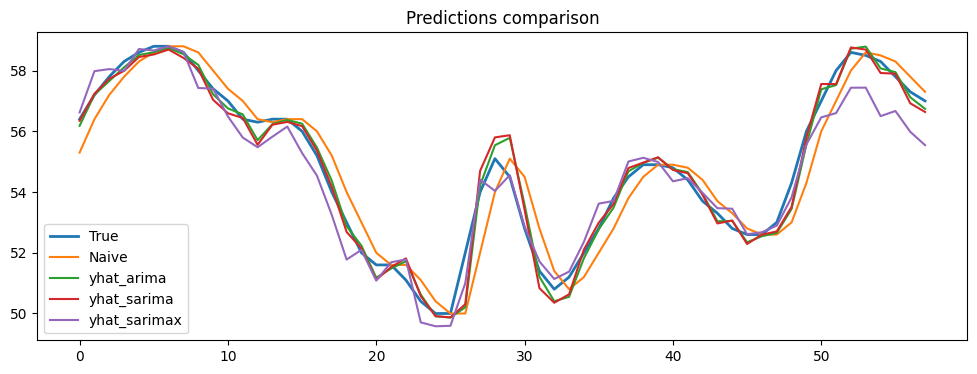

In [ ]:
plot_predictions(
    y_test,
    [yhat_naive,yhat_arima,yhat_sarima,yhat_sarimax],
    ["Naive", "yhat_arima",'yhat_sarima','yhat_sarimax']
)


In [ ]:
results_df = pd.DataFrame(results).sort_values("MAE")
results_df


,model,MAE,RMSE,MAPE,SMAPE
6,"ARIMA(2,0,1) - 1step",0.296922,0.420665,0.548429,0.549273
1,Linear Regression,0.321831,0.455883,0.583689,0.585871
7,"SARIMA(2,0,1)x(1,0,1,5) - 1step",0.322503,0.444576,0.594321,0.595058
2,Linear Regression - Ridge regularization (L2),0.342477,0.486359,0.620633,0.623171
8,"SARIMAX(2,0,1)x(1,0,1,10) + exog - 1step",0.508667,0.661762,0.920335,0.925443
0,Baseline: CO2(t-1),0.618966,0.786853,1.138253,1.140531
4,XGBoost,0.763145,1.133473,1.362618,1.379646
3,Random Forest,0.842918,1.293244,1.506659,1.529137
5,CatBoost,0.847767,1.256612,1.510970,1.531957


# Next Steps: Multi-Step Forecasting with Exogenous Features

## The Challenge We Face

You've successfully trained a model to predict one step ahead using `input_gas` as a feature. But in reality, you want to predict **50 steps ahead** (50 seconds into the future).

**The Problem:** To predict step 50, you would need to know `input_gas` values for steps 1-49... but you don't have them yet!

This is a fundamental challenge in time series forecasting when you have exogenous variables (external input features).

---

## Your Options

Here are the main approaches to solve this problem:

### **Option 1: Pure Autoregressive (Ignore Exogenous Features)**

**Approach:** Only use past sensor values to predict future values. Don't use `input_gas` at all.

**How it works:**
- Train model: `sensor(t+1) = f(sensor(t-1), sensor(t-2), sensor(t-3), ...)`
- For 50 steps: Loop 50 times, feeding each prediction back as input

**Pros:**
- Simple to implement
- No dependency on unknown future inputs

**Cons:**
- You're ignoring potentially valuable information from `input_gas`
- May be less accurate if input gas significantly affects the sensor

**When to use:** Good baseline approach, or when exogenous features have minimal impact

---

### **Option 2: Forecast Both Inputs and Outputs**

**Approach:** Build two models - one to predict future `input_gas` values, and another to predict `sensor` values using the predicted inputs.

**How it works:**
1. Model A predicts: `input_gas(t+1), input_gas(t+2), ..., input_gas(t+50)`
2. Model B predicts: `sensor(t+i)` using predicted `input_gas(t+i)`

**Pros:**
- Utilizes all available information
- Can capture relationships between input and output

**Cons:**
- Errors compound: bad `input_gas` predictions → bad `sensor` predictions
- More complex to implement and tune
- Uncertainty grows rapidly with prediction horizon

**When to use:** When exogenous features are important AND somewhat predictable

---

### **Option 3: Assume Future Inputs Are Known**

**Approach:** Use actual future input values if they're available in your application.

**How it works:**
- In many industrial settings, input values are planned or scheduled in advance
- Examples: setpoints, production schedules, control sequences

**Pros:**
- Most accurate approach
- Straightforward to implement

**Cons:**
- Only applicable if you genuinely have access to future input values

**When to use:** When your system has planned or scheduled input values (check if this applies to your use case!)

---

### **Option 4: Multi-Output Direct Forecasting (No Exogenous Features)**

**Approach:** Train a single model that outputs all 50 future steps simultaneously, without using exogenous features.

**How it works:**
- Train: `[sensor(t+1), ..., sensor(t+50)] = f(sensor(t-1), sensor(t-2), ...)`
- Predict: Get all 50 values in one shot, no loop

**Pros:**
- No error compounding from recursive predictions
- Can be more accurate for distant horizons

**Cons:**
- Cannot use exogenous features (functionally similar to Option 1)
- Requires training a more complex model (50 outputs instead of 1)

**When to use:** When you want to avoid error accumulation and exogenous features aren't critical

---

## Questions to Consider

As you implement these approaches, think about:

- How does prediction error grow over the 50-step horizon?
- Which features are most important for accurate long-term predictions?
- What's the trade-off between model complexity and prediction accuracy?
- In a real system, how would you decide which approach to use?

